# Adjoint Operator Validation
Plots analytical vs numerical adjoint gradients for `adjointWrtI` and `adjointWrtE`.

Files are written by stTestCore when `dump_dir` is set.
- `_dqd*_analytical.txt` — full adjoint image (286×286), col-major
- `_pixels.txt` — all pixels: `nx ny analytical numerical rel_err abs_err`

In [15]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import os
_cwd = Path(os.path.abspath(''))
_candidates = [_cwd / 'dump', _cwd.parent / 'dump']
DUMP = next((p for p in _candidates if p.exists()), _candidates[-1])

def load_image(path):
    """Load a stTestCore txt dump (col-major, # shape: W H header)."""
    path = Path(path)
    W = H = None
    with open(path) as f:
        for line in f:
            if line.startswith('# shape:'):
                W, H = map(int, line.split()[2:4])
                break
    data = np.loadtxt(path, comments='#', dtype=np.float32)
    return data.reshape(W, H, order='F').T   # (H, W)

def load_pixels(path):
    """Load _pixels.txt → raw array (N, 6): nx ny ana num rel abs."""
    return np.loadtxt(path, comments='#')

def pixels_to_images(data, H, W):
    nx = data[:, 0].astype(int); ny = data[:, 1].astype(int)
    ana = np.full((H, W), np.nan); num = np.full((H, W), np.nan)
    rel = np.full((H, W), np.nan); abs_ = np.full((H, W), np.nan)
    ana[ny, nx] = data[:, 2]; num[ny, nx] = data[:, 3]
    rel[ny, nx] = data[:, 4]; abs_[ny, nx] = data[:, 5]
    return ana, num, rel, abs_

def plot_4panel(ana_img, num_img, rel_img, title, figname):
    # Use 98th percentile of |analytical| so outliers clip and signal fills the colorbar
    vmax = np.nanpercentile(np.abs(ana_img), 98)
    if vmax == 0: vmax = np.nanmax(np.abs(ana_img))
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(title, fontsize=13)
    im0 = axes[0].imshow(ana_img, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
    axes[0].set_title('Analytical'); plt.colorbar(im0, ax=axes[0])
    im1 = axes[1].imshow(num_img, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
    axes[1].set_title('Numerical'); plt.colorbar(im1, ax=axes[1])
    diff = ana_img - num_img
    dmax = np.nanmax(np.abs(diff))
    im2 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-dmax, vmax=dmax, origin='lower')
    axes[2].set_title(f'Difference  (max={dmax:.2e})'); plt.colorbar(im2, ax=axes[2])
    im3 = axes[3].imshow(rel_img, cmap='hot_r', vmin=0, origin='lower')
    axes[3].set_title(f'Rel error  (max={np.nanmax(rel_img):.2e})'); plt.colorbar(im3, ax=axes[3])
    plt.tight_layout(); plt.savefig(figname, dpi=150); plt.show()

def plot_scatter(data, label, figname, thresh_frac=0.01):
    """Scatter filtered to signal-bearing pixels (max(|ana|,|num|) > thresh_frac * peak)."""
    ana = data[:, 2]; num = data[:, 3]
    threshold = np.max(np.abs(ana)) * thresh_frac
    mask = np.maximum(np.abs(ana), np.abs(num)) > threshold
    a_vals = ana[mask]; n_vals = num[mask]
    corr = np.corrcoef(a_vals, n_vals)[0, 1] if len(a_vals) > 1 else float('nan')

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(a_vals, n_vals, s=2, alpha=0.4)
    lim = max(np.abs(a_vals).max(), np.abs(n_vals).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1, label='y=x')
    ax.set_xlabel('Analytical adjoint'); ax.set_ylabel('Numerical adjoint')
    ax.set_title(f'{label}\n{mask.sum()} signal pixels  R={corr:.6f}')
    ax.legend(); ax.set_aspect('equal')
    plt.tight_layout(); plt.savefig(figname, dpi=150); plt.show()
    print(f'  threshold={threshold:.2e}  signal={mask.sum()}/{len(data)}  R={corr:.6f}')
    print(f'  max_rel={data[:,4].max():.3e}  max_abs={data[:,5].max():.3e}')

print('Helpers loaded')

Helpers loaded


## Forward inputs / output (Task 1, 286×286)

`E_pad`, `I_pad` (padded inputs) and `R_gpu = srkForwardOaS(E, I)` dumped from Task 1.

E_pad: (286, 286)  range [-1.848, 2.926]
I_pad: (286, 286)  range [-2.298, 2.527]
R_gpu: (256, 256)  range [-1.233e-01, 1.442e-01]


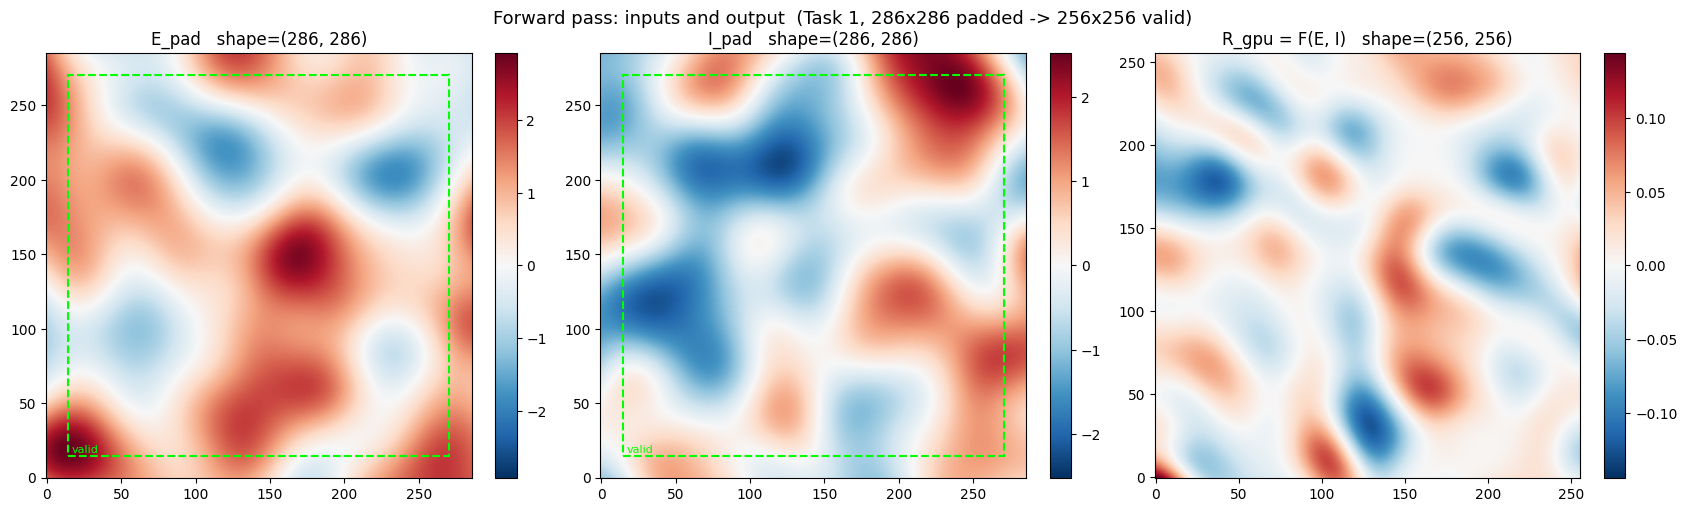

In [16]:
fwd = DUMP / 'forward'
E_pad = load_image(fwd / 'E_pad.txt')
I_pad = load_image(fwd / 'I_pad.txt')
R_gpu = load_image(fwd / 'R_gpu.txt')

print(f'E_pad: {E_pad.shape}  range [{E_pad.min():.3f}, {E_pad.max():.3f}]')
print(f'I_pad: {I_pad.shape}  range [{I_pad.min():.3f}, {I_pad.max():.3f}]')
print(f'R_gpu: {R_gpu.shape}  range [{R_gpu.min():.3e}, {R_gpu.max():.3e}]')

EROSION = 15
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Forward pass: inputs and output  (Task 1, 286x286 padded -> 256x256 valid)', fontsize=13)

for ax, img, name in zip(axes, [E_pad, I_pad, R_gpu], ['E_pad', 'I_pad', 'R_gpu = F(E, I)']):
    vmax = np.nanmax(np.abs(img))
    im = ax.imshow(img, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
    ax.set_title(f'{name}   shape={img.shape}')
    plt.colorbar(im, ax=ax, fraction=0.046)

# Mark the valid region on the padded inputs (E_pad, I_pad)
for ax in axes[:2]:
    rect = plt.Rectangle((EROSION-0.5, EROSION-0.5),
                         286-2*EROSION, 286-2*EROSION,
                         fill=False, edgecolor='lime', lw=1.5, linestyle='--')
    ax.add_patch(rect)
    ax.text(EROSION+2, EROSION+2, 'valid', color='lime', fontsize=8)

plt.tight_layout()
plt.savefig('forward_inputs_output.png', dpi=150)
plt.show()

## adjointWrtI (seed=1)

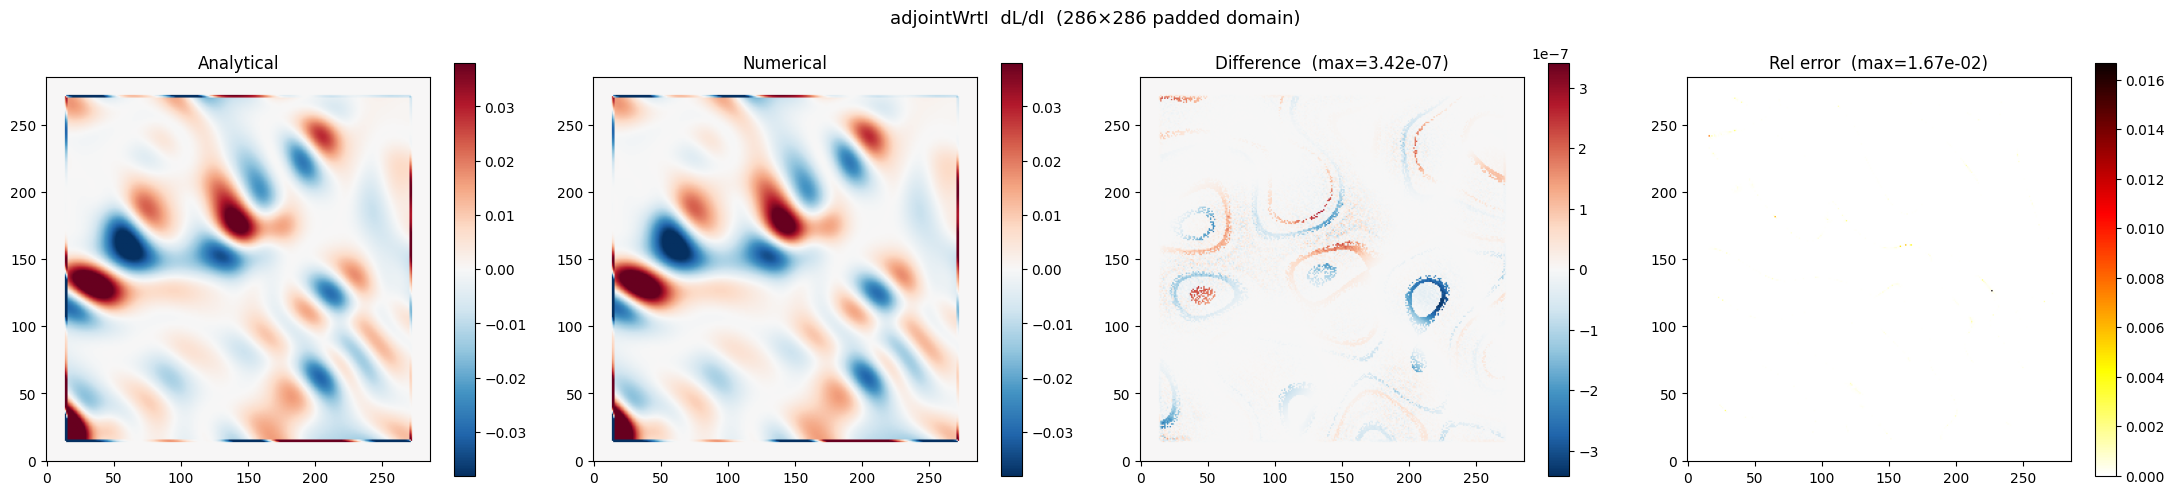

In [17]:
d = DUMP / 'wrtI_seed1'
label = 'adjointWrtI_seed_1'

data_I = load_pixels(d / f'{label}_pixels.txt')
H = W = 286  # N_LARGE × N_LARGE padded domain
ana_I, num_I, rel_I, _ = pixels_to_images(data_I, H, W)

plot_4panel(ana_I, num_I, rel_I,
            'adjointWrtI  dL/dI  (286×286 padded domain)',
            'adjointWrtI_comparison.png')


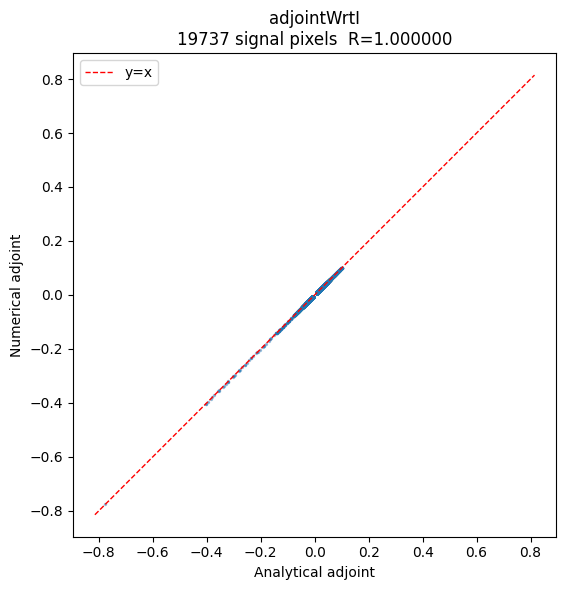

  threshold=7.76e-03  signal=19737/81796  R=1.000000
  max_rel=1.669e-02  max_abs=3.420e-07


In [18]:
plot_scatter(data_I, 'adjointWrtI', 'adjointWrtI_scatter.png')

## adjointWrtE (seed=1)

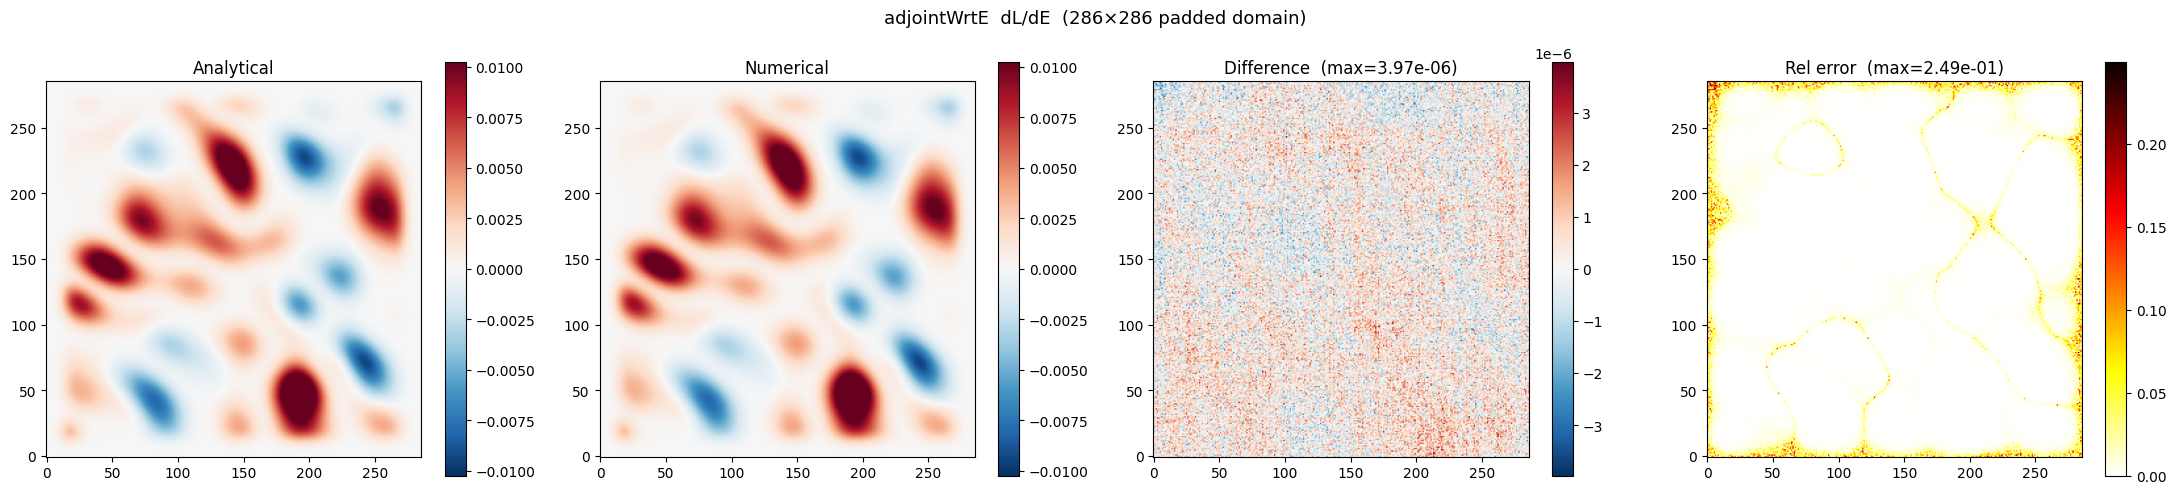

In [19]:
d = DUMP / 'wrtE_seed1'
label = 'adjointWrtE_seed_1'

data_E = load_pixels(d / f'{label}_pixels.txt')
H = W = 286
ana_E, num_E, rel_E, _ = pixels_to_images(data_E, H, W)

plot_4panel(ana_E, num_E, rel_E,
            'adjointWrtE  dL/dE  (286×286 padded domain)',
            'adjointWrtE_comparison.png')


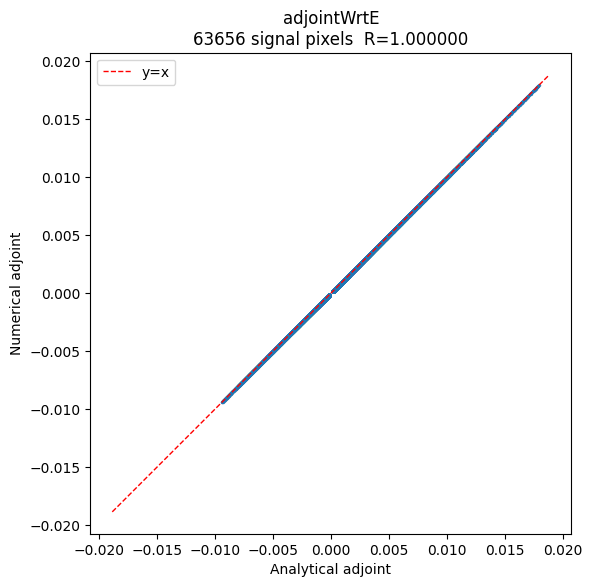

  threshold=1.79e-04  signal=63656/81796  R=1.000000
  max_rel=2.491e-01  max_abs=3.968e-06


In [20]:
plot_scatter(data_E, 'adjointWrtE', 'adjointWrtE_scatter.png')

## Side-by-side: wrtI and wrtE analytical gradients

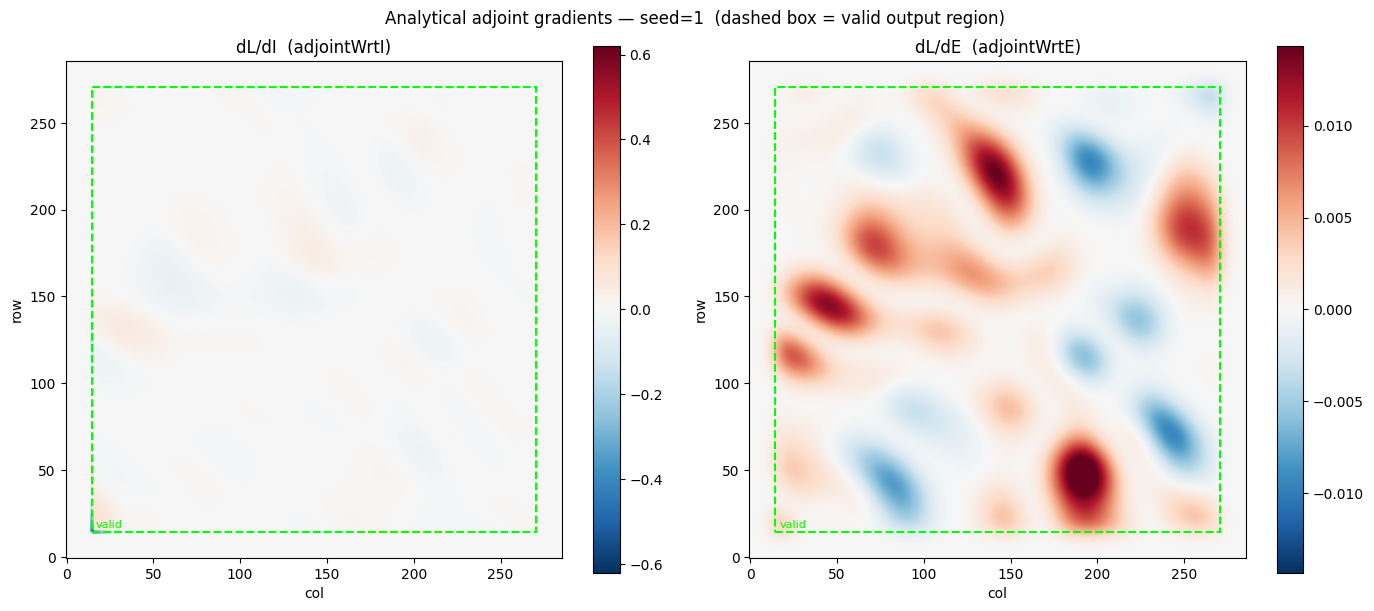

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vi = np.nanmax(np.abs(ana_I)) * 0.8
ve = np.nanmax(np.abs(ana_E)) * 0.8

im0 = axes[0].imshow(ana_I, cmap='RdBu_r', vmin=-vi, vmax=vi, origin='lower')
axes[0].set_title('dL/dI  (adjointWrtI)', fontsize=12)
axes[0].set_xlabel('col'); axes[0].set_ylabel('row')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ana_E, cmap='RdBu_r', vmin=-ve, vmax=ve, origin='lower')
axes[1].set_title('dL/dE  (adjointWrtE)', fontsize=12)
axes[1].set_xlabel('col'); axes[1].set_ylabel('row')
plt.colorbar(im1, ax=axes[1])

# Mark erosion border
EROSION = 15
for ax in axes:
    rect = plt.Rectangle((EROSION-0.5, EROSION-0.5),
                          286-2*EROSION, 286-2*EROSION,
                          fill=False, edgecolor='lime', lw=1.5, linestyle='--')
    ax.add_patch(rect)
    ax.text(EROSION+2, EROSION+2, 'valid', color='lime', fontsize=8)

plt.suptitle('Analytical adjoint gradients — seed=1  (dashed box = valid output region)', fontsize=12)
plt.tight_layout()
plt.savefig('adjoint_both_analytical.png', dpi=150)
plt.show()